<a href="https://colab.research.google.com/github/Prachetaganguly/pytorch-for-neural-networks/blob/main/Pytorch_for_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [37]:
#Create a Model cls that inherits the nn.module
class Model(nn.Module):
    # Input layer (4 features) → Hidden1 → Hidden2 → Output (3 classes)

    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [38]:
#Pick a manual seed for randomization
torch.manual_seed(35)
#Create an instance of the model
model = Model()

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [40]:
url='https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df=pd.read_csv(url)

In [41]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [42]:
my_df['species']=my_df['species'].replace('setosa',0.0)
my_df['species']=my_df['species'].replace('versicolor',1.0)
my_df['species']=my_df['species'].replace('virginica',2.0)
my_df

/tmp/ipykernel_938/2411446934.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species']=my_df['species'].replace('virginica',2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [43]:
#Train Test Split! Split X,y
X= my_df.drop('species',axis=1)
y=my_df['species']

In [44]:
#Convert these to numpy arrays
X=X.values
y=y.values

In [45]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=35) #Test size is 20% and train is 80%



In [48]:
#Convert X features to float tensors
X_train=torch.FloatTensor(X_train)
X_test=torch.FloatTensor(X_test)


In [49]:
#Convert y labels to tensor long
y_train=torch.LongTensor(y_train)
y_test=torch.LongTensor(y_test)


In [50]:
#Set the criterion of model to measure error
criterion=nn.CrossEntropyLoss()
#Choose Adam Optimizer, set lr(if error doesn't go down after a bunch of iterations(epochs) lower the lr)
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)


In [51]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [52]:
#Train our Model!
#Epochs? (one run thru all the training data in our network)
epochs=100
losses=[]
for i in range(epochs):
  #Go forward to get a prediction
  y_pred=model.forward(X_train)

  #Measure the loss/error, gonna be high at first
  loss=criterion(y_pred,y_train)
  losses.append((loss).detach().numpy())

  #print every 10 epoch
  if i%10==0:
    print(f'Epoch:{i} Loss:{loss}')

  #Do some back propagation:take the error rate of fwd propagation n feed it back to tweek the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch:0 Loss:1.168838620185852
Epoch:10 Loss:0.9641608595848083
Epoch:20 Loss:0.707249104976654
Epoch:30 Loss:0.47081369161605835
Epoch:40 Loss:0.3232300877571106
Epoch:50 Loss:0.2051076740026474
Epoch:60 Loss:0.12805040180683136
Epoch:70 Loss:0.09108898788690567
Epoch:80 Loss:0.07480044662952423
Epoch:90 Loss:0.0666050985455513


Text(0.5, 0, 'epoch')

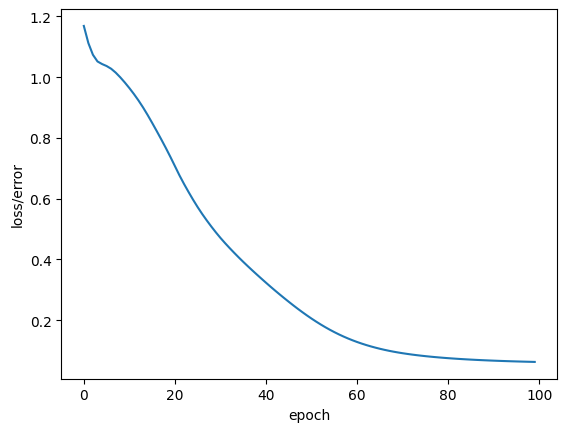

In [53]:
#Graph it out!
plt.plot(range(epochs),losses)
plt.ylabel("loss/error")
plt.xlabel("epoch")


In [54]:
#Evaluate Model on Test Data Set(validate model on test set)
with torch.no_grad(): #Basically turn off back propagation
  y_eval=model.forward(X_test) #X_test are features from our test set, y_eval will be the predictions
  loss=criterion(y_eval,y_test)



In [55]:
loss

tensor(0.0447)

In [56]:
correct=0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val=model.forward(data)
    #will tell us what type of flower class our network thinks it is
    print(f'{i+1:2}. {str(y_val):38} {y_test[i]} \t{y_val.argmax().item()}')

    #Correct or not
    if y_val.argmax().item()==y_test[i]:
      correct+=1

print(f'We got {correct} correct!')

 1. tensor([-1.5369,  4.6760, -1.9926])    1 	1
 2. tensor([-2.7085,  4.6497, -0.1084])    1 	1
 3. tensor([-9.7305,  4.4200, 11.4597])    2 	2
 4. tensor([-5.6836,  4.5157,  4.8314])    1 	2
 5. tensor([ 11.2913,   5.3133, -23.3981]) 0 	0
 6. tensor([-10.1184,   4.5452,  11.9872]) 2 	2
 7. tensor([-7.8281,  4.3322,  8.4312])    2 	2
 8. tensor([-0.4337,  4.5894, -3.7468])    1 	1
 9. tensor([-3.7885,  4.6167,  1.6785])    1 	1
10. tensor([ 11.1128,   5.2331, -23.0446]) 0 	0
11. tensor([-4.1555,  4.3597,  2.5223])    1 	1
12. tensor([-10.2296,   4.7004,  12.0028]) 2 	2
13. tensor([ 11.3159,   5.3336, -23.4764]) 0 	0
14. tensor([-9.6338,  4.7731, 10.9766])    2 	2
15. tensor([ 10.3003,   5.0091, -21.5385]) 0 	0
16. tensor([-8.7284,  4.0133, 10.1827])    2 	2
17. tensor([-1.4164,  4.3349, -1.9188])    1 	1
18. tensor([ 10.0958,   4.7592, -20.9804]) 0 	0
19. tensor([ 10.3527,   4.8478, -21.4020]) 0 	0
20. tensor([ 10.6043,   5.0009, -22.0296]) 0 	0
21. tensor([-2.5895,  5.0036, -0.5973]) 